# Imports

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Task 1 — Data Loading & Exploration

In [4]:
# Display the first 10 rows.
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
# Checking the number of rows and columns and identifying missing values if any.
print(f"Shape : {df.shape}")
df.isna().sum()

Shape : (545, 13)


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [3]:
# Reconfirming no missing values and identifying the target, numeric and categorical columns.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# Task 2 — Data Cleaning

In [36]:
print("No missing values....")

No missing values....


In [10]:
# Checking for duplicates
print(f"Number of duplicates : {df.duplicated().sum()}")

Number of duplicates : 0


In [12]:
# No duplicates found but removing just in case.
df = df.drop_duplicates()

In [14]:
# Separating Target Column
x = df.drop("price", axis=1)
y = df["price"]

In [15]:
# Checking shapes
print(x.shape)  # (n_samples, n_features)
print(y.shape)  # (n_samples,)

(545, 12)
(545,)


In [17]:
# Categorical columns
cat_cols = x.select_dtypes(include='object').columns

# Numerical columns
num_cols = x.select_dtypes(exclude='object').columns

print(f"Categorical : {cat_cols}")
print(f"Numeric : {num_cols}")
print("Extraction of categorical and numeric columns complete....")

Categorical : Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')
Numeric : Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')
Extraction of categorical and numeric columns complete....


In [20]:
# Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

x_en = preprocessor.fit_transform(x)
print(f"Shape after encoding : {x_en.shape}")

Shape after encoding : (545, 13)


In [22]:
# Checking Feature Correlation wrt to Price Column
new_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = list(new_cat_features) + list(num_cols)

df_encoded = pd.DataFrame(x_en, columns=all_features)
df_encoded['price'] = y

corr_with_price = (
    df_encoded.corr()['price']
    .drop('price')
    .sort_values(key=abs, ascending=False)
)

print(corr_with_price)

area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
furnishingstatus_unfurnished      -0.280587
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
Name: price, dtype: float64


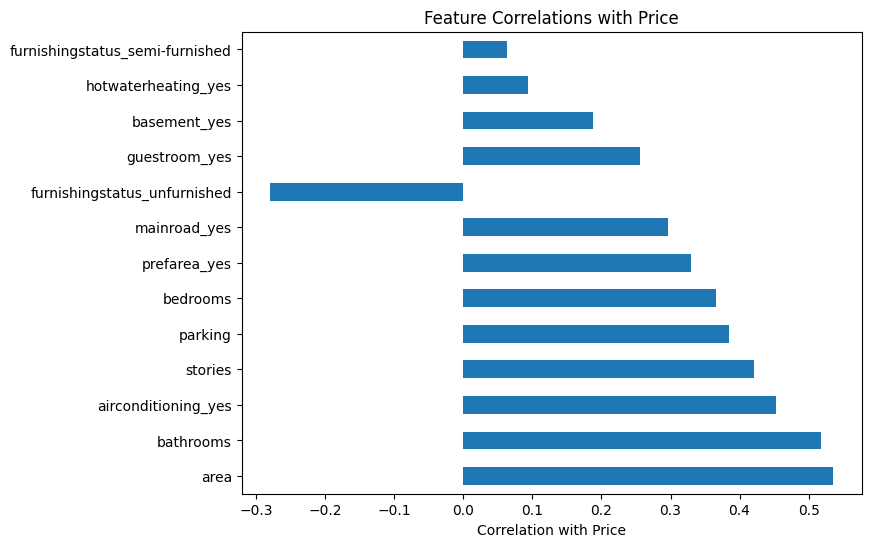

In [24]:
# figure of correlation
corr_with_price.plot(kind='barh', figsize=(8, 6))
plt.xlabel("Correlation with Price")
plt.title("Feature Correlations with Price")
plt.show()

# Task 3 — Model Building

In [26]:
# Split and LR Training
# Train model

xtrain, xtest, ytrain, ytest = train_test_split(
    x_en, y, test_size=0.2, random_state=19
)

model = LinearRegression()
model.fit(xtrain, ytrain)

LinearRegression()

In [27]:
# Prediction and Evaluation

# Predict on test set
ypred = model.predict(xtest)

# Metrics
mae = mean_absolute_error(ytest, ypred)
rmse = np.sqrt(mean_squared_error(ytest, ypred))
r2 = r2_score(ytest, ypred)

# Print results
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE  : 779346.22
RMSE : 1061502.67
R² Score : 0.6729


In [29]:
# RandomForest Regressor

# Create model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(xtrain, ytrain)

# Predict
ypred_rf = rf.predict(xtest)

# Evaluate
mae = mean_absolute_error(ytest, ypred_rf)
rmse = np.sqrt(mean_squared_error(ytest, ypred_rf))
r2 = r2_score(ytest, ypred_rf)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE  : 865137.05
RMSE : 1210613.82
R² Score : 0.5745


In [32]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                            Feature  Importance
8                              area    0.431285
10                        bathrooms    0.206160
12                          parking    0.060642
4               airconditioning_yes    0.060026
11                          stories    0.046280
7      furnishingstatus_unfurnished    0.040114
9                          bedrooms    0.039056
5                      prefarea_yes    0.036515
2                      basement_yes    0.029112
3               hotwaterheating_yes    0.017369
1                     guestroom_yes    0.015497
6   furnishingstatus_semi-furnished    0.011556
0                      mainroad_yes    0.006388


In [34]:
# Multicollinearity Check
xtrain_df = pd.DataFrame(xtrain, columns=all_features)
corr = xtrain_df.corr()

# Show pairs with correlation > 0.8
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

print(high_corr[high_corr.abs() > 0.8])

Series([], dtype: float64)


In [35]:
print("Since no feature is highly correlated to each other, feature selection is still deemed unnecessary for a dataset of this size.")

Since no feature is highly correlated to each other, feature selection is still deemed unnecessary for a dataset of this size.


In [37]:
# Comparison
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [779346.22, 865137.05],
    'RMSE': [1061502.67, 1210613.82],
    'R2 Score': [0.6729, 0.5745]
})

print(results)

               Model        MAE        RMSE  R2 Score
0  Linear Regression  779346.22  1061502.67    0.6729
1      Random Forest  865137.05  1210613.82    0.5745


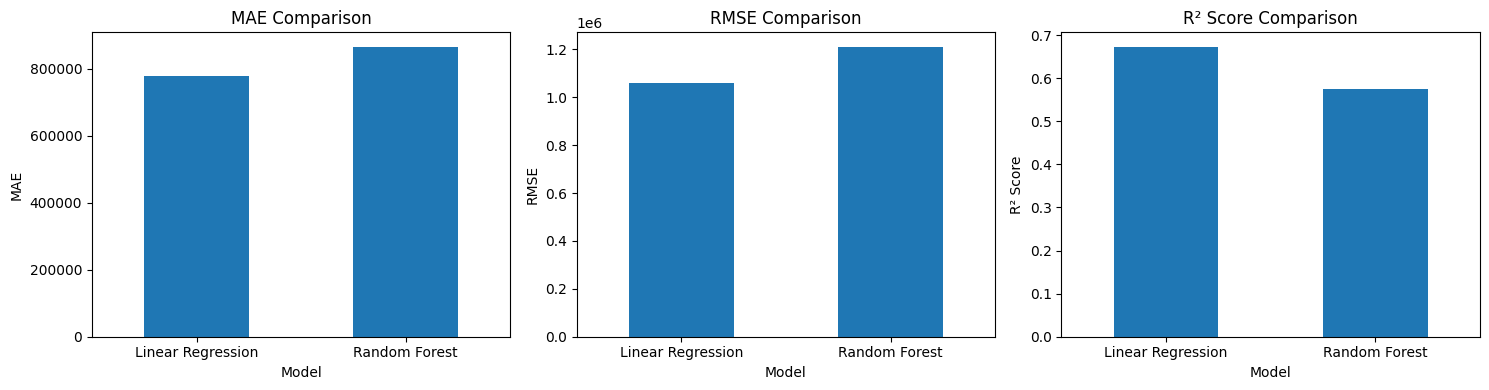

In [39]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MAE
results.plot(
    x='Model',
    y='MAE',
    kind='bar',
    ax=axes[0],
    legend=False
)
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=0)

# RMSE
results.plot(
    x='Model',
    y='RMSE',
    kind='bar',
    ax=axes[1],
    legend=False
)
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=0)

# R² Score
results.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    ax=axes[2],
    legend=False
)
axes[2].set_title("R² Score Comparison")
axes[2].set_ylabel("R² Score")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Task 4 — Visualization

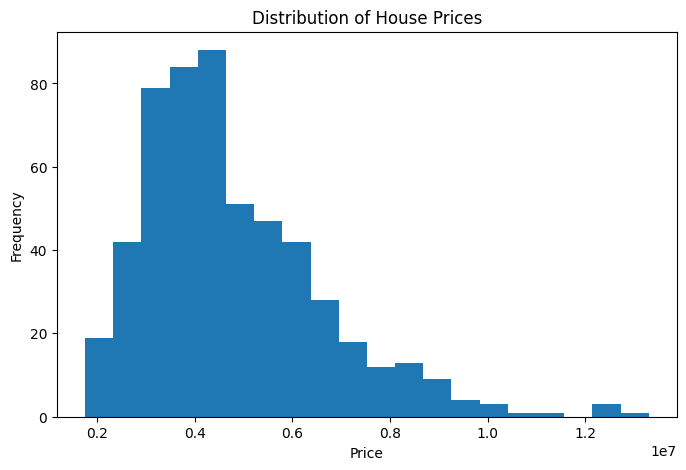

In [40]:
# Chart 1 — Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=20)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

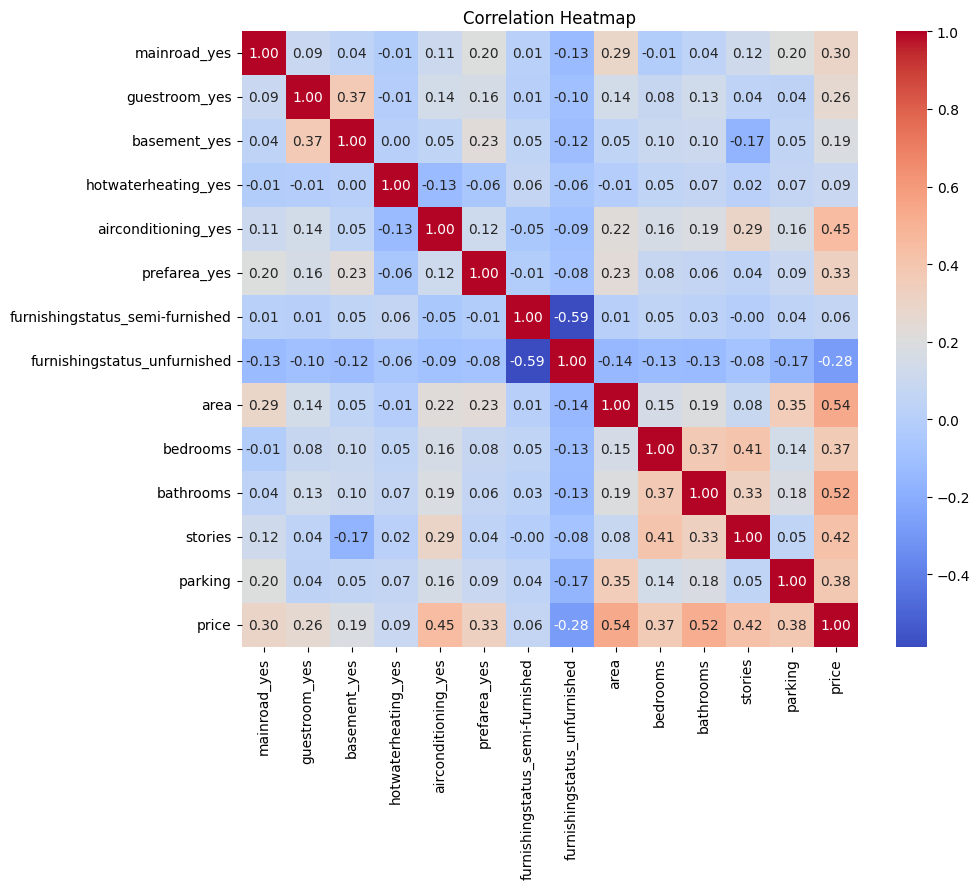

In [41]:
# Chart 2 — Correlation Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)

plt.title('Correlation Heatmap')
plt.show()

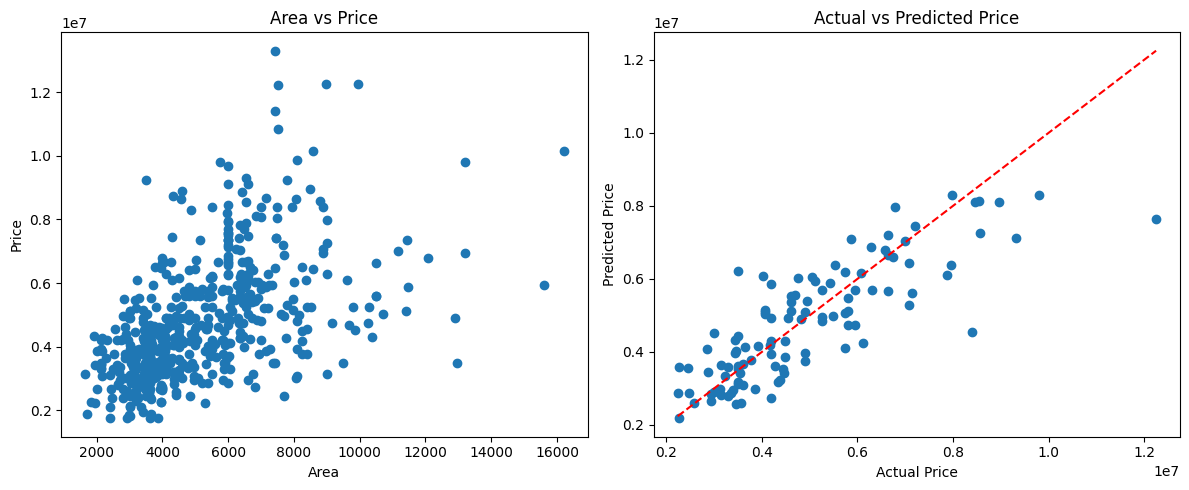

In [43]:
# Chart 3 — 1×2 Grid of actual vs. predicted price scatter plot and price vs. area scatter plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Area vs Price
axes[0].scatter(df['area'], df['price'])
axes[0].set_title('Area vs Price')
axes[0].set_xlabel('Area')
axes[0].set_ylabel('Price')

# Right: Actual vs Predicted
axes[1].scatter(ytest, ypred)
axes[1].plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    'r--'
)

axes[1].set_title('Actual vs Predicted Price')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

# Task 5 — Insights & Summary

The analysis showed that **area** and **number of bathrooms** have the strongest influence on house prices, followed by features such as air conditioning, number of stories, and parking spaces. The Linear Regression model achieved an **R² score of 0.6729**, meaning it was able to explain about **67% of the variation** in house prices, which indicates reasonably good predictive performance. One surprising finding was that **Random Forest performed worse than Linear Regression**, suggesting that the relationships in the data are largely linear despite the presence of categorical features. Additionally, features such as hot water heating had only a weak correlation with price. Based on these findings, a real estate business should focus on properties with larger areas, more bathrooms, and modern amenities, as these characteristics are most strongly associated with higher house values.
